# EDA
This part of the project focueses on the exploration on the data.
The main questions asked are:
- What does the dataset look like?
    - How many columns? 
    - How many rows?
- What features are there?
- How does the data quality look like at first glance?
- Do we got missing values?
- How is the data distributed?
- any noticeable properties?
- first hypotheses

## Notice
- Python Version used: 3.13.0

- Data information:
    - instant: record index
	- dteday : date
	- season : season (1:springer, 2:summer, 3:fall, 4:winter)
	- yr : year (0: 2011, 1:2012)
	- mnth : month ( 1 to 12)
	- hr : hour (0 to 23)
	- holiday : weather day is holiday or not (extracted from http://dchr.dc.gov/page/holiday-schedule)
	- weekday : day of the week
	- workingday : if day is neither weekend nor holiday is 1, otherwise is 0.
	+ weathersit : 
		- 1: Clear, Few clouds, Partly cloudy, Partly cloudy
		- 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
		- 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
		- 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
	- temp : Normalized temperature in Celsius. The values are divided to 41 (max)
	- atemp: Normalized feeling temperature in Celsius. The values are divided to 50 (max)
	- hum: Normalized humidity. The values are divided to 100 (max)
	- windspeed: Normalized wind speed. The values are divided to 67 (max)
	- casual: count of casual users
	- registered: count of registered users
	- cnt: count of total rental bikes including both casual and registered


## Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Load data

In [6]:
df = pd.read_csv("hour.csv")

## Data Overview

In [9]:
print("rows:", df.shape[0])
print("columns:", df.shape[1])

df.info()

rows: 17379
columns: 17
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [ ]:
df.describe().T # for better viewing purposes, .T was chosen to have the table format

,count,mean,std,min,25%,50%,75%,max
instant,17379.0,8690.000000,5017.029500,1.00,4345.5000,8690.0000,13034.5000,17379.0000
season,17379.0,2.501640,1.106918,1.00,2.0000,3.0000,3.0000,4.0000
yr,17379.0,0.502561,0.500008,0.00,0.0000,1.0000,1.0000,1.0000
mnth,17379.0,6.537775,3.438776,1.00,4.0000,7.0000,10.0000,12.0000
hr,17379.0,11.546752,6.914405,0.00,6.0000,12.0000,18.0000,23.0000
holiday,17379.0,0.028770,0.167165,0.00,0.0000,0.0000,0.0000,1.0000
weekday,17379.0,3.003683,2.005771,0.00,1.0000,3.0000,5.0000,6.0000
workingday,17379.0,0.682721,0.465431,0.00,0.0000,1.0000,1.0000,1.0000
weathersit,17379.0,1.425283,0.639357,1.00,1.0000,1.0000,2.0000,4.0000
temp,17379.0,0.496987,0.192556,0.02,0.3400,0.5000,0.6600,1.0000


### Summary:
- The dataset contains as of 26.04.2026: 
    - 17379 observations
    - 17 features:
        - instant 
        - dteday 
        - season
        - yr
        - mnth
        - hr
        - holiday
        - weekday
        - workingday
        - weathersit
        - temp
        - atemp
        - hum
        - windspeed
        - casual
        - registered
        - cnt
        
    - both numerical and categorical variables
    

## Missing Values and Data Quality

In [10]:
df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

## Summary
There are no missing values in the dataset,
therefore the dataset is very clean and does not require imputation

## Target Variable Analysis

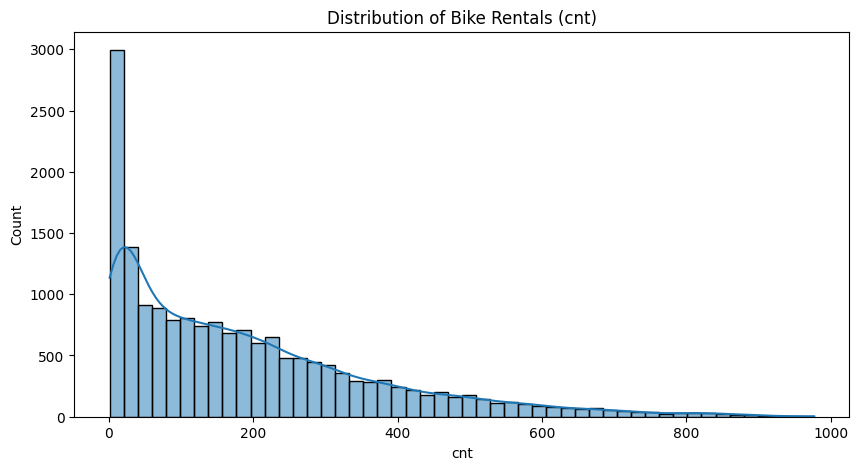

In [12]:
plt.figure(figsize=(10,5))
sns.histplot(df["cnt"], bins=50, kde=True)
plt.title("Distribution of Bike Rentals (cnt)")
plt.show()

### Interpretation
- The distribution is **right-skewed**.
- Most observations correspond to low or moderate demand, while a few show very high demand.
- This suggests the presence of **peak hours** (e.g., commuting times).

## Comparison: Casual vs Registered Users

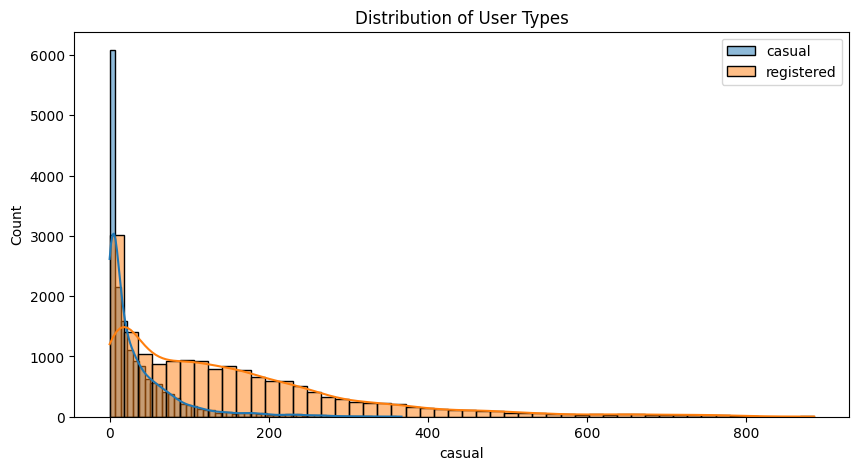

In [13]:
plt.figure(figsize=(10,5))
sns.histplot(df["casual"], bins=50, kde=True, label="casual")
sns.histplot(df["registered"], bins=50, kde=True, label="registered")
plt.legend()
plt.title("Distribution of User Types")
plt.show()

### Interpretation

- Registered users significantly outnumber casual users.
- This suggests that the system is primarily used by **regular users (e.g., commuters)**.

## Usage by Hour of Day

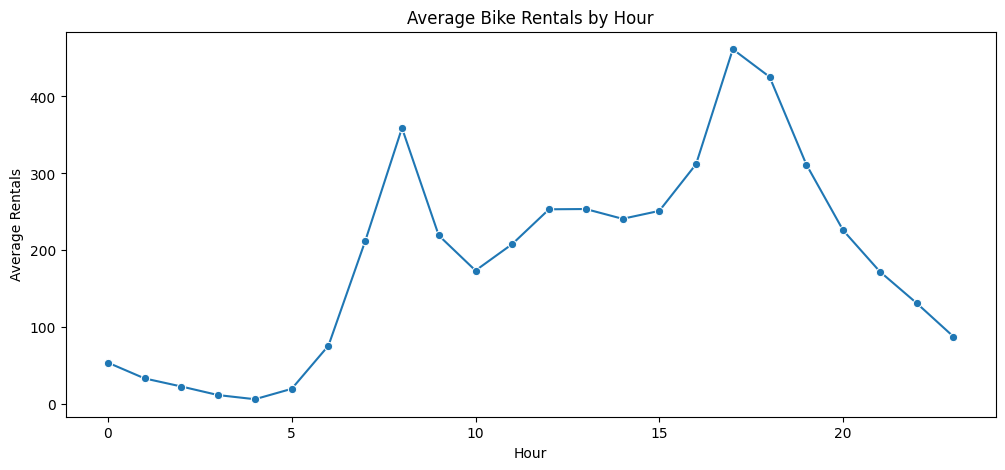

In [14]:
hourly_avg = df.groupby("hr")["cnt"].mean()

plt.figure(figsize=(12,5))
sns.lineplot(x=hourly_avg.index, y=hourly_avg.values, marker="o")
plt.title("Average Bike Rentals by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Rentals")
plt.show()

### Interpretation

- Clear peaks are visible:
  - Morning hours (commuting to work)
  - Evening hours (returning home)
- This indicates a strong **commuting pattern**.

## Usage by Weekday

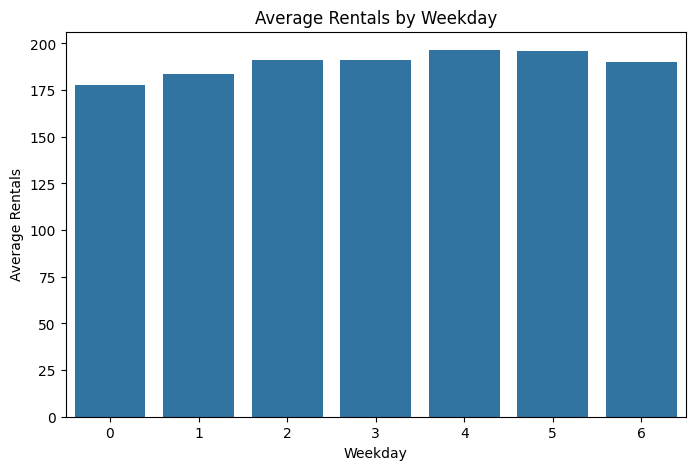

In [15]:
weekday_avg = df.groupby("weekday")["cnt"].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=weekday_avg.index, y=weekday_avg.values)
plt.title("Average Rentals by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average Rentals")
plt.show()

### Interpretation

- Differences across weekdays are present but not extreme.
- Usage appears relatively stable, with slight variations.

## Seasonal Effects (Monthly Analysis)

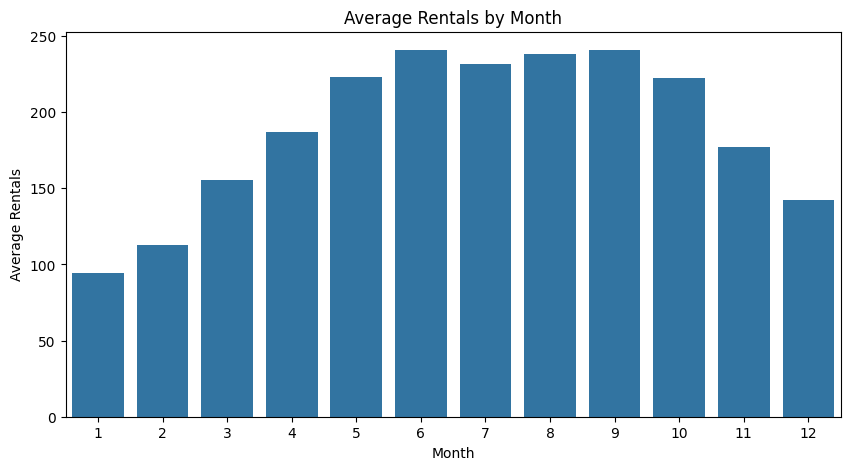

In [16]:
month_avg = df.groupby("mnth")["cnt"].mean()

plt.figure(figsize=(10,5))
sns.barplot(x=month_avg.index, y=month_avg.values)
plt.title("Average Rentals by Month")
plt.xlabel("Month")
plt.ylabel("Average Rentals")
plt.show()

### Interpretation

- Higher usage during warmer months.
- Lower usage during winter.
- Indicates a clear **seasonal pattern**.

## Impact of Weather Conditions

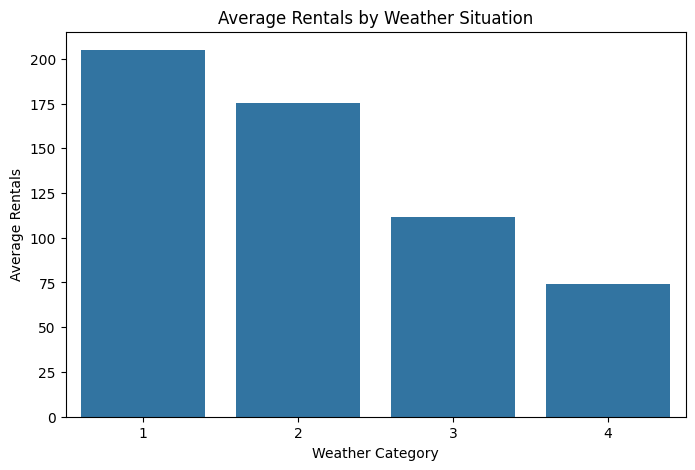

In [17]:
weather_avg = df.groupby("weathersit")["cnt"].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=weather_avg.index, y=weather_avg.values)
plt.title("Average Rentals by Weather Situation")
plt.xlabel("Weather Category")
plt.ylabel("Average Rentals")
plt.show()

### Interpretation

- Worse weather conditions lead to fewer rentals.
- Weather is a strong influencing factor.

## Impact of Temperature

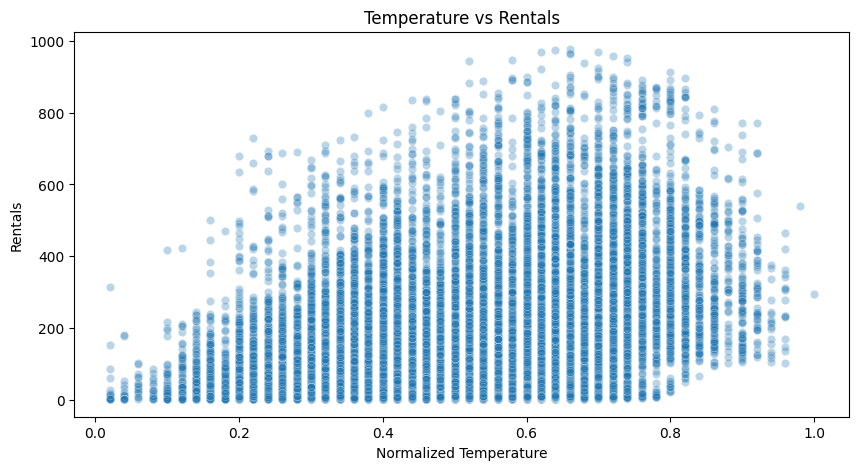

In [18]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x="temp", y="cnt", alpha=0.3)
plt.title("Temperature vs Rentals")
plt.xlabel("Normalized Temperature")
plt.ylabel("Rentals")
plt.show()

### Interpretation

- A positive relationship is visible:
  - Higher temperature → more rentals
- The relationship is not strictly linear but shows a clear trend.

## Correlation Analysis

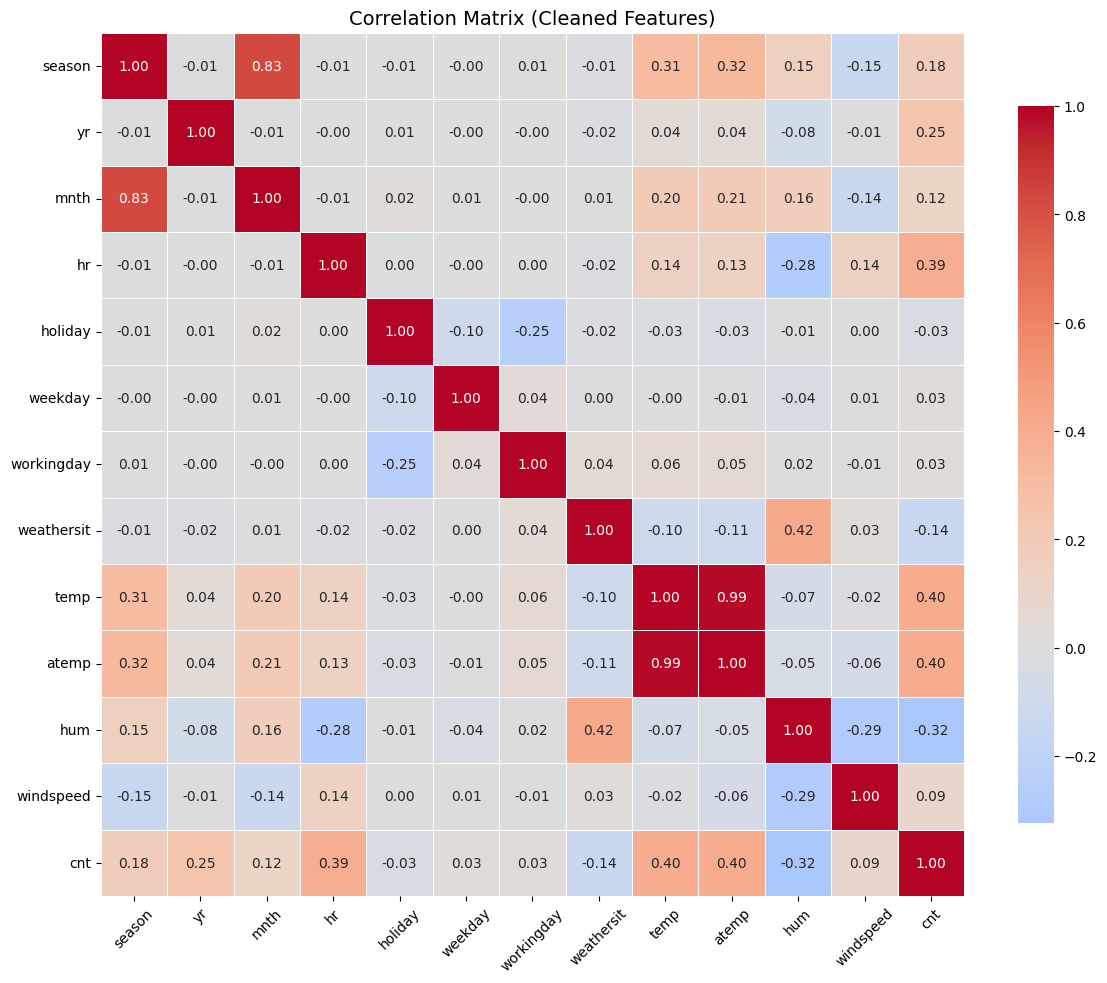

In [22]:
corr_df = df.drop(columns=["instant", "casual", "registered"])
corr = corr_df.corr(numeric_only=True)
plt.figure(figsize=(12,10))
sns.heatmap(
    corr,
    annot=True,          
    fmt=".2f",           
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix (Cleaned Features)", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretation

- The strongest positive correlation is observed between `registered` and `cnt`, which is expected as it directly contributes to the total count.
- Temperature (`temp`) shows a moderate positive correlation with bike rentals.
- Humidity (`hum`) exhibits a negative relationship, indicating that higher humidity reduces demand.
- Temporal features such as hour (`hr`) also show structured relationships.

However, correlation does not imply causation and further modeling is required to validate these relationships.

## Interaction: Hour vs Working Day

This analysis examines how bike usage varies across hours, depending on whether it is a working day or not.

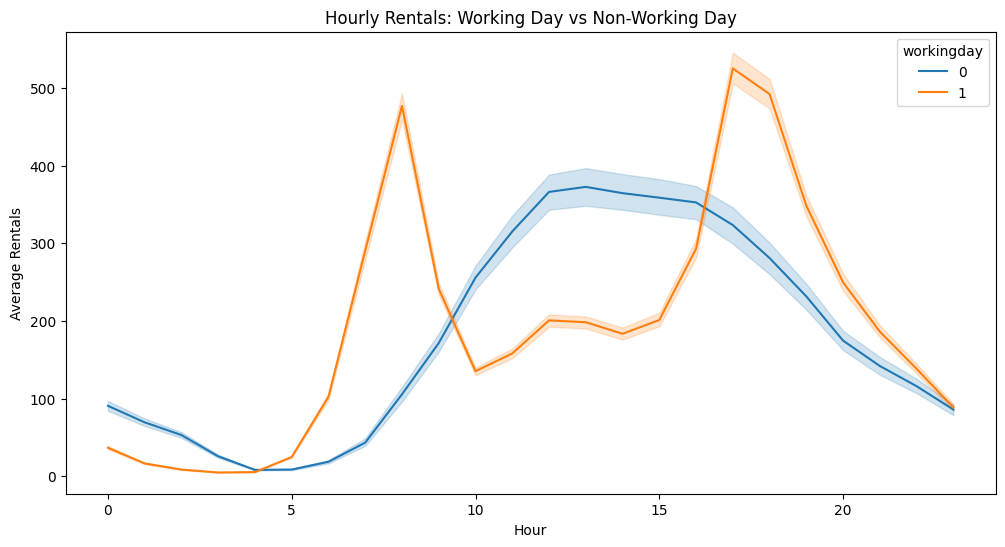

In [23]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x="hr", y="cnt", hue="workingday", estimator="mean")
plt.title("Hourly Rentals: Working Day vs Non-Working Day")
plt.xlabel("Hour")
plt.ylabel("Average Rentals")
plt.show()

### Interpretation

- On working days:
  - Strong peaks in the morning and evening → commuting behavior
- On non-working days:
  - Flatter curve, peak shifts to midday
- → Clear behavioral difference between workdays and leisure days

## Interaction: Season vs Hour

This analysis explores how seasonal effects interact with daily usage patterns.

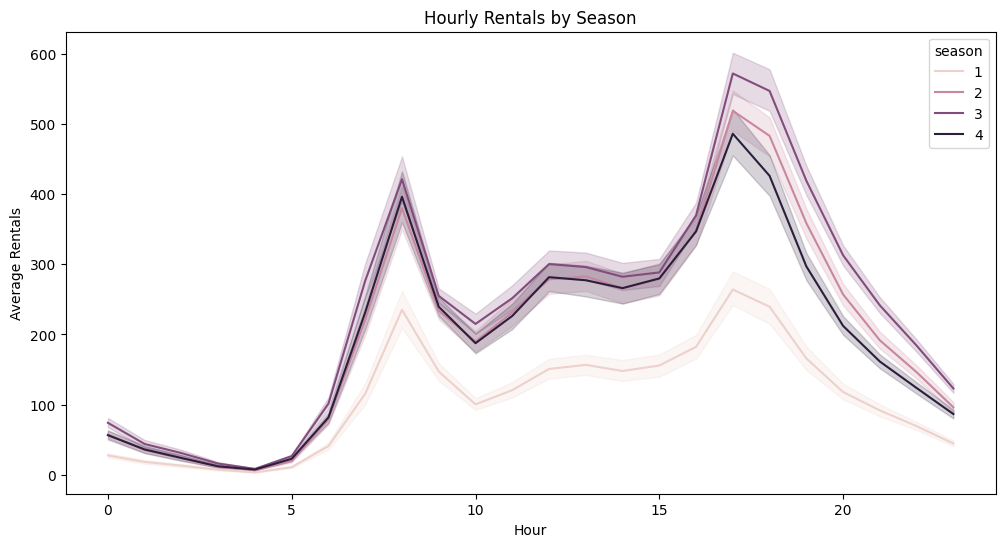

In [24]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x="hr", y="cnt", hue="season", estimator="mean")
plt.title("Hourly Rentals by Season")
plt.xlabel("Hour")
plt.ylabel("Average Rentals")
plt.show()

### Interpretation

- All seasons show similar daily structure
- However:
  - Higher peaks in summer
  - Lower usage in winter
- → Season affects magnitude, not pattern shape

## Distribution of Rentals by Weather Condition

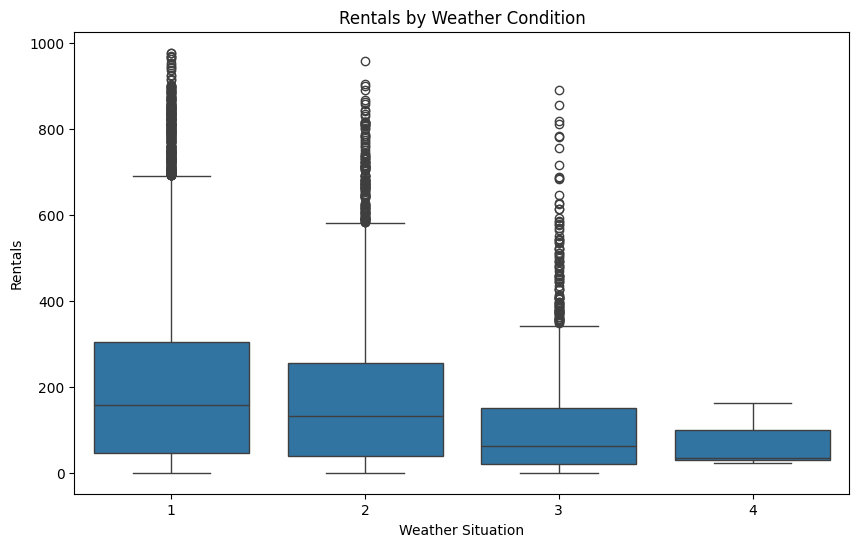

In [25]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="weathersit", y="cnt")
plt.title("Rentals by Weather Condition")
plt.xlabel("Weather Situation")
plt.ylabel("Rentals")
plt.show()

### Interpretation

- Clear drop in median rentals with worse weather
- More variability under good conditions
- → Good weather enables high peaks, bad weather limits usage

## Distribution of Rentals by Hour

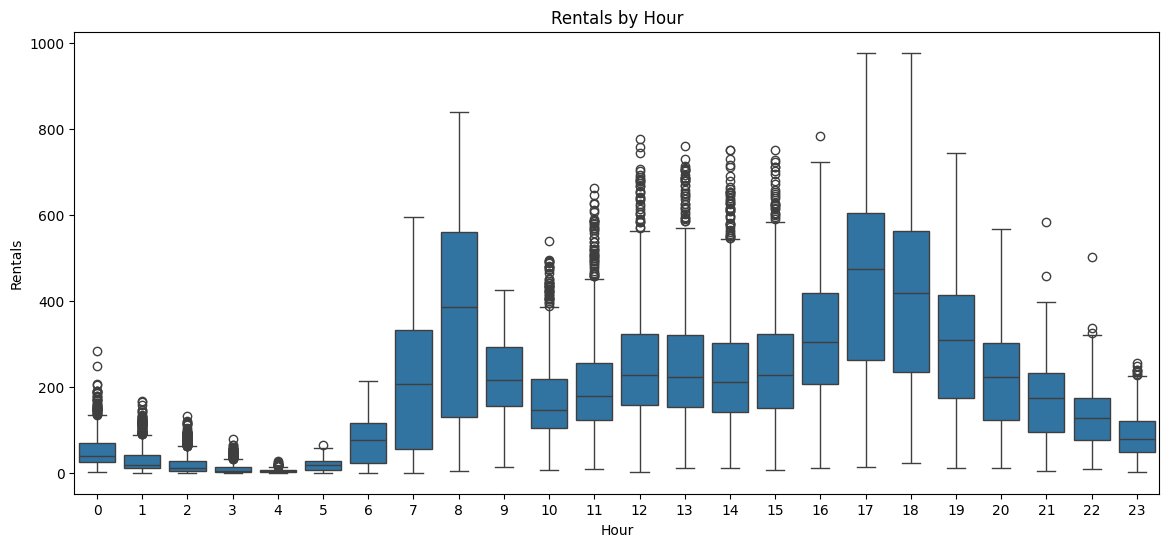

In [26]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df, x="hr", y="cnt")
plt.title("Rentals by Hour")
plt.xlabel("Hour")
plt.ylabel("Rentals")
plt.show()

### Interpretation

- Peak hours show:
  - Higher medians
  - Larger spread
- Off-peak hours:
  - Low variability
- → Demand uncertainty increases during peak times

## Interaction: Temperature vs Rentals by Season

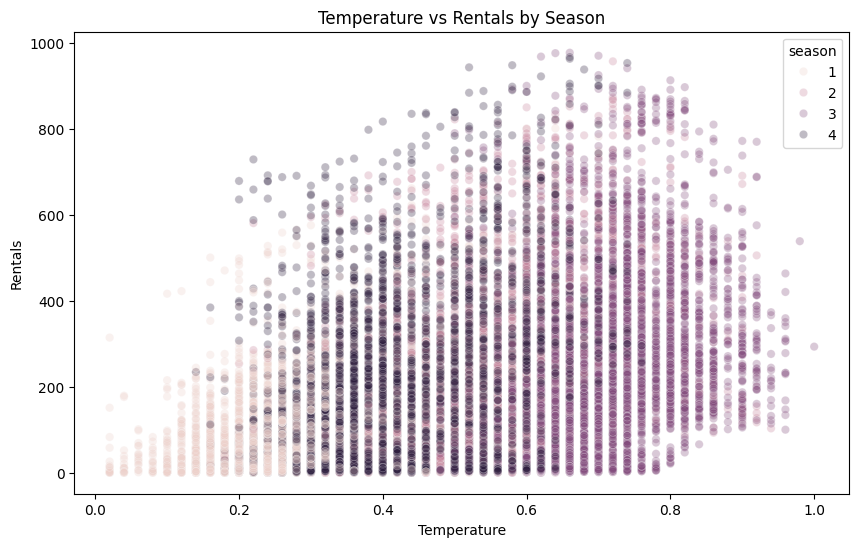

In [27]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="temp", y="cnt", hue="season", alpha=0.3)
plt.title("Temperature vs Rentals by Season")
plt.xlabel("Temperature")
plt.ylabel("Rentals")
plt.show()

### Interpretation

- Positive relationship in all seasons
- But:
  - Stronger effect in spring/summer
- → Temperature impact is context-dependent

## Combined Effect: Humidity and Wind Speed

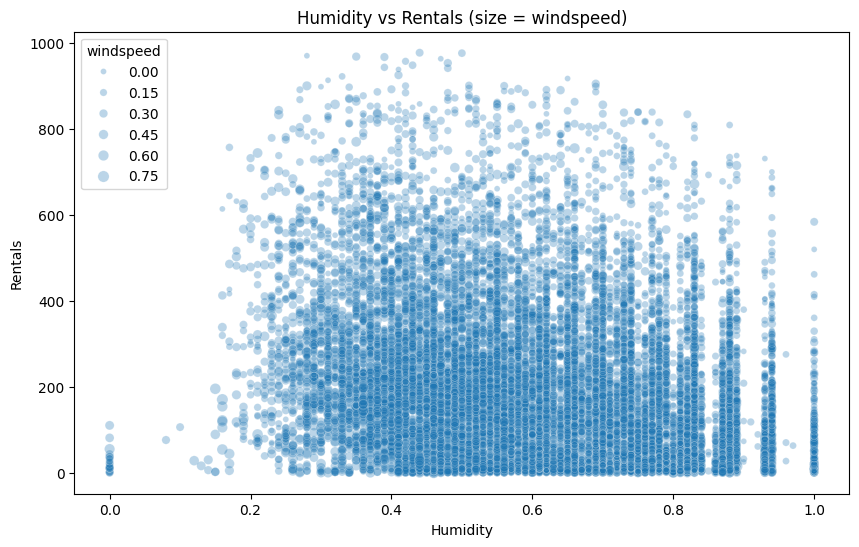

In [28]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="hum", y="cnt", size="windspeed", alpha=0.3)
plt.title("Humidity vs Rentals (size = windspeed)")
plt.xlabel("Humidity")
plt.ylabel("Rentals")
plt.show()

### Interpretation

- Higher humidity → lower rentals
- Larger points (high windspeed):
  - Tend to cluster at lower rental values
- → Combined negative environmental effect

## User Behavior: Casual vs Registered by Hour

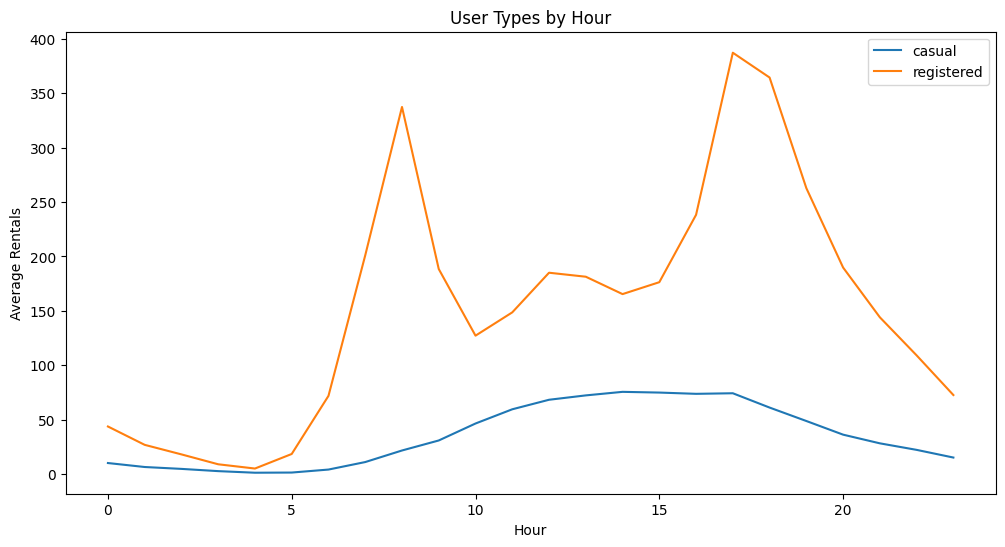

In [29]:
hourly_users = df.groupby("hr")[["casual", "registered"]].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=hourly_users, x="hr", y="casual", label="casual")
sns.lineplot(data=hourly_users, x="hr", y="registered", label="registered")
plt.title("User Types by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Rentals")
plt.show()

### Interpretation

- Registered users:
  - Strong commuting peaks
- Casual users:
  - Peak around midday
- → Completely different usage behavior

## Multi-Dimensional Analysis using FacetGrid

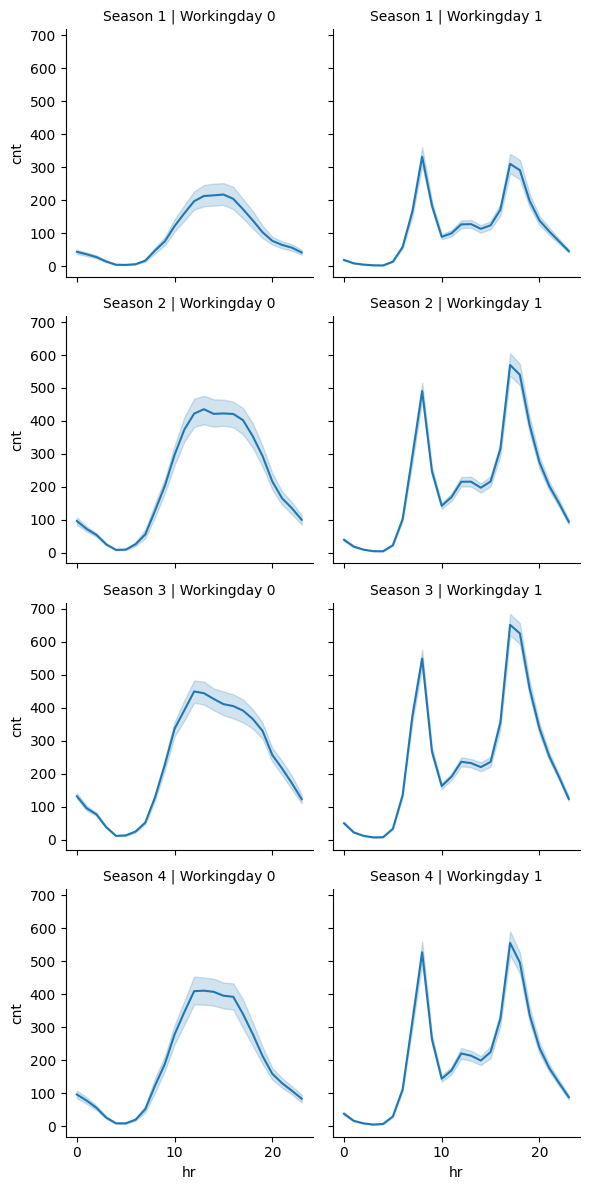

In [30]:
g = sns.FacetGrid(df, col="workingday", row="season", height=3)
g.map_dataframe(sns.lineplot, x="hr", y="cnt")
g.set_titles("Season {row_name} | Workingday {col_name}")
plt.show()

### Interpretation

- Combines:
  - Time of day
  - Season
  - Working day
- Shows:
  - Consistent patterns across dimensions
  - Strongest demand in summer + working days
- → Confirms robustness of observed effects

## Feature Importance (Correlation with Target)

In [33]:
corr_df = df.drop(columns=["instant", "casual", "registered"])

numeric_corr_df = corr_df.select_dtypes(include=["number"])

corr_target = numeric_corr_df.corr()["cnt"].sort_values(ascending=False)

corr_target

cnt           1.000000
temp          0.404772
atemp         0.400929
hr            0.394071
yr            0.250495
season        0.178056
mnth          0.120638
windspeed     0.093234
workingday    0.030284
weekday       0.026900
holiday      -0.030927
weathersit   -0.142426
hum          -0.322911
Name: cnt, dtype: float64

### Interpretation

- Strongest drivers:
  - registered
  - temp
- Negative influence:
  - humidity
- → Good starting point for modeling

## Notable Patterns

- Strong time-of-day effects with clear commuting peaks on working days.
- Registered users dominate overall demand and show typical commuter behavior.
- Casual users exhibit a different pattern, with peak usage during midday.
- Weather and temperature significantly influence demand.
- Seasonal effects impact the magnitude of rentals but not the overall daily pattern.
- Environmental factors such as humidity and wind speed negatively affect usage.

## Data-Driven Hypotheses

1. Bike rental demand is strongly influenced by the time of day, with pronounced peaks during commuting hours on working days.
2. Registered users are the primary drivers of demand and exhibit structured commuting behavior, while casual users are more active during leisure hours.
3. Weather conditions significantly impact demand, with unfavorable weather reducing bike usage.
4. Temperature positively influences demand, though the strength of this relationship varies across seasons.
5. Seasonal effects primarily affect the intensity of demand rather than its daily structure.
6. Environmental factors such as high humidity and wind speed jointly reduce bike rental activity.

## Summary of Exploratory Data Analysis

### Dataset Overview
The dataset consists of 17,379 hourly observations of a bike-sharing system, including temporal, weather-related, and usage features. The target variable is `cnt`, representing the total number of bike rentals.

The dataset is well-structured and contains no missing values, making it suitable for further analysis and modeling.

---

### Key Findings

#### 1. Demand Distribution
- The target variable `cnt` is **right-skewed**, indicating many low-demand periods and a few high-demand peaks.
- This suggests the presence of **specific peak usage times** rather than uniform demand.

---

#### 2. Temporal Patterns
- Strong **hourly patterns** were observed:
  - Peaks in the **morning and evening**, indicating commuting behavior.
- **Working days vs non-working days**:
  - Working days show clear commuting peaks.
  - Non-working days show more evenly distributed demand with midday peaks.
- **Seasonality**:
  - Demand is higher in warmer seasons and lower in colder ones.
  - However, the daily pattern remains consistent across seasons.

---

#### 3. User Behavior
- **Registered users dominate** overall demand.
- Distinct usage patterns:
  - Registered users → commuting peaks
  - Casual users → leisure-oriented midday usage
- This indicates **two fundamentally different user groups**.

---

#### 4. Weather Effects
- Weather has a strong impact on demand:
  - Better weather → higher rentals
  - Worse weather → reduced demand
- **Temperature** shows a positive relationship with rentals.
- **Humidity and wind speed** negatively affect usage.
- Combined environmental effects further reduce demand.

---

#### 5. Feature Relationships
- Strong correlations with the target variable:
  - `registered` (expected, but excluded due to leakage)
  - `temp` (positive influence)
- Negative influence:
  - `hum` (humidity)
- Temporal features (e.g., `hr`) show structured but non-linear effects.

---

### Data Quality Assessment
- No missing values detected.
- Some features required preprocessing:
  - Removal of non-informative (`instant`)
  - Exclusion of leakage features (`casual`, `registered`)
  - Handling of categorical variables (encoding or labeling)

---

### Notable Patterns

- Clear **commuting behavior patterns**
- Strong **seasonal and weather influence**
- Distinct **user group behaviors**
- Interaction effects between:
  - Time × working day
  - Season × temperature
  - Weather × environmental factors

---

### Data-Driven Hypotheses

1. Bike rental demand is strongly influenced by the time of day, especially during commuting hours.
2. Registered users are the primary drivers of demand, while casual users exhibit different behavioral patterns.
3. Weather conditions significantly impact demand, with unfavorable conditions reducing usage.
4. Temperature positively affects demand, with varying strength depending on the season.
5. Seasonal effects influence the magnitude of demand but not its daily structure.
6. Environmental factors such as humidity and wind speed jointly reduce bike rental activity.

---

### Conclusion

The analysis reveals that bike rental demand is driven by a combination of **temporal patterns, user behavior, and environmental conditions**.

These insights provide a strong foundation for predictive modeling, where temporal features, weather variables, and user segmentation are expected to play a central role.

## Next Steps

### 1. Problem Formalization

The task can be defined as a **supervised regression problem**, where the goal is to predict the hourly bike rental demand (`cnt`) based on temporal and environmental features.

It is important to clearly define:
- The target variable (`cnt`)
- The input features (e.g., time, weather, calendar variables)
- The intended use of the model (e.g., short-term prediction vs. general pattern modeling)

---

### 2. Feature Engineering

Based on the insights from the exploratory data analysis, additional features can be derived to improve model performance:

- **Temporal transformations**
  - Cyclical encoding of time variables (e.g., hour of day)
  - Differentiation between weekdays and weekends

- **Interaction features**
  - Combined effects such as temperature × season
  - Weather-related interactions

- **Aggregations**
  - Rolling averages (e.g., demand in previous hours)
  - Lag features to capture temporal dependencies

These transformations help the model better capture non-linear relationships and patterns.

---

### 3. Data Preprocessing

Before modeling, the dataset must be prepared:

- Handling categorical variables (e.g., encoding)
- Removing irrelevant features (e.g., identifiers)
- Avoiding target leakage (e.g., excluding `casual` and `registered`)
- Optional: scaling numerical features (for certain models)

